### Exercise 1

#### Part 1

The lecture note’s AlexNet has 5 conv layers and 3 fully connected layers; after the last pooling layer, the feature map is flattened to size $256\times 5\times 5=6400$. The note specifically flags the FC matrices $6400\times4096$ and $4096\times4096$ as AlexNet’s efficiency bottleneck. 

Assume FP32 parameters, so each parameter takes **4 bytes**.

**1. Convolutional layer parameter memory**

For a conv layer:
$$
\text{params}=C_{\text{out}}\times C_{\text{in}}\times k_h\times k_w + C_{\text{out}}
$$
Using the Fashion-MNIST version with **1 input channel**:

| Layer                        | Parameters |   Memory |
| ---------------------------- | ---------: | -------: |
| Conv1: $1\to96, 11\times11$  |     11,712 | 0.047 MB |
| Conv2: $96\to256, 5\times5$  |    614,656 |  2.46 MB |
| Conv3: $256\to384, 3\times3$ |    885,120 |  3.54 MB |
| Conv4: $384\to384, 3\times3$ |  1,327,488 |  5.31 MB |
| Conv5: $384\to256, 3\times3$ |    884,992 |  3.54 MB |

Total convolution parameters:
$$
3.72\text{ million parameters}
$$
Memory:
$$
3.72\text{M}\times 4 \approx 14.9\text{ MB}
$$

**2. Fully connected layer parameter memory**

| Layer              | Parameters |   Memory |
| ------------------ | ---------: | -------: |
| FC1: $6400\to4096$ | 26,218,496 | 104.9 MB |
| FC2: $4096\to4096$ | 16,781,312 |  67.1 MB |
| FC3: $4096\to10$   |     40,970 |  0.16 MB |

Total fully connected parameters:
$$
43.04\text{ million parameters}
$$
Memory:
$$
43.04\text{M}\times 4 \approx 172.2\text{ MB}
$$
**Which one dominates?**

The **fully connected layers dominate** parameter memory.
$$
\frac{172.2}{14.9}\approx 11.6
$$
So the FC layers use about **11–12 times more parameter memory** than the convolutional layers.

#### Part 2

Use **MACs** = multiply–accumulate operations. If counting separate multiplications and additions as FLOPs, multiply these numbers by about 2.

For each conv layer:
$$
\text{MACs}=C_{\text{out}}H_{\text{out}}W_{\text{out}}C_{\text{in}}k_hk_w
$$
The lecture note’s AlexNet uses five conv layers followed by FC layers $6400\to4096\to4096\to10$. 

| Layer |          Output shape |   MACs |
| ----- | --------------------: | -----: |
| Conv1 |  $96\times54\times54$ |  33.9M |
| Conv2 | $256\times26\times26$ | 415.3M |
| Conv3 | $384\times12\times12$ | 127.4M |
| Conv4 | $384\times12\times12$ | 191.1M |
| Conv5 | $256\times12\times12$ | 127.4M |

Total conv cost:
$$
895.1\text{M MACs}
$$
For fully connected layers:
$$
\text{MACs}=d_{\text{in}}d_{\text{out}}
$$

| Layer |      Matrix size |  MACs |
| ----- | ---------------: | ----: |
| FC1   | $6400\times4096$ | 26.2M |
| FC2   | $4096\times4096$ | 16.8M |
| FC3   |   $4096\times10$ | 0.04M |

Total FC cost:
$$
43.0\text{M MACs}
$$
So computationally:
$$
\frac{895.1}{43.0}\approx 20.8
$$
The **convolutional layers dominate computation**, by about **21 times**.


#### Part 3

This exercise is really asking about the relationship between **compute** and **memory systems** in deep learning hardware.

A GPU is not only limited by FLOPs. Very often, performance is limited by how fast data can move through memory.

There are three key memory properties:

1. **Bandwidth** — how many bytes/sec can be moved
2. **Latency** — how long it takes to access memory
3. **Size (capacity)** — how much data can fit close to the processor

The effects are somewhat different for **training** and **inference**.

---

**1. Memory bandwidth**

Bandwidth determines how quickly we can feed data to the compute units.

If the GPU can do many FLOPs but cannot receive data fast enough, the cores sit idle.

---

**Example: fully connected layers**

Recall AlexNet FC1:
$$
6400 \times 4096
$$
This layer has:

* many parameters (~26M)
* relatively modest computation reuse

Each weight is often used only once per example.

So the GPU must continuously:

* read weights from memory
* multiply them
* discard them

This makes FC layers often **memory-bandwidth bound**.

---

**Example: convolutions**

Convolutions reuse weights many times across spatial locations.

For example, a $3\times3$ kernel is reused at every pixel location.

So after loading a kernel once:

* many computations can be performed

Hence convolutions are usually more **compute-bound** than FC layers.

---

**2. Memory latency**

Latency is the delay before data arrives.

Even if bandwidth is high, random or poorly organized access patterns can stall the processor.

GPUs hide latency by:

* massive parallelism
* switching between many threads

Still, latency matters when:

* memory accesses are irregular
* cache misses occur
* batch sizes are small

---

**CNN implication**

Convolutions have very regular access patterns:

* neighboring pixels reused
* contiguous tensor layouts

This works well with:

* caches
* prefetching
* shared memory

FC layers can have worse locality because matrices are huge.

---

**3. Memory size (capacity)**

Capacity determines:

* maximum model size
* batch size
* activation storage

This is crucial in deep learning.

---

**Training vs. inference**

This is the most important distinction.

---

**4. Memory effects during inference**

Inference only needs:

* forward pass
* weights
* current activations

After a layer is computed, earlier activations can often be discarded.

Thus inference memory usage is relatively modest.

The bottleneck is often:

* weight loading
* bandwidth
* latency

especially for large FC layers or transformer models.

---

**5. Memory effects during training**

Training is much more memory-intensive.

Why?

Because backpropagation requires storing intermediate activations.

For each layer we need:

* forward activations
* gradients
* optimizer states (Adam needs extra tensors)
* temporary buffers

---

**Rough rule**

Training memory is often:

$$
2\text{–}6\times
$$

larger than inference memory.

Sometimes much larger.

---

**6. Read/write differences**

Training also requires far more writes.

Inference mostly:

* read weights
* compute outputs

Training additionally must:

* write activations
* write gradients
* update parameters
* store optimizer states

So training stresses:

* memory bandwidth
* memory capacity
* memory traffic

much more heavily.


### Exercise 2

You optimize by **balancing compute throughput with memory bandwidth**, not by maximizing either one alone.

A good way to think about it is the **roofline model**:
$$
\text{Performance} = \min\left(
\text{peak compute},
\text{memory bandwidth}\times\text{arithmetic intensity}
\right)
$$
where
$$
\text{arithmetic intensity} = \frac{\text{FLOPs}}{\text{bytes moved}}
$$

So the key question is:

> For the target workload, do we run out of FLOPs first, or do we run out of memory bandwidth first?


### Exercise 3

Engineers no longer benchmark AlexNet because:


1. it is computationally outdated,

The lecture note already hints at AlexNet’s main weakness:

* enormous fully connected layers
* large parameter count
* inefficient memory usage


2. it underutilizes modern hardware,


3. its workload is unrepresentative of modern models,


4. better benchmark suites now exist,


5. and performance on AlexNet no longer meaningfully predicts real-world ML system performance.

AlexNet answered the 2012 question:

``“Can deep CNNs trained on GPUs beat classical vision methods?”``

That question has already been decisively answered.


### Exercise 4

In [11]:
!pip install torch torchvision pandas matplotlib jupyter ipykernel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [jupyter]console]


In [1]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA L4


In [2]:
batch_size = 128
num_epochs = 30

transform_lenet = transforms.Compose([
    transforms.ToTensor()
])

transform_alexnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_lenet = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform_lenet
)
test_lenet = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform_lenet
)

train_alexnet = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform_alexnet
)
test_alexnet = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform_alexnet
)

train_loader_lenet = DataLoader(train_lenet, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)   # pin_memory=True can speed up data transfer to GPU
test_loader_lenet = DataLoader(test_lenet, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

train_loader_alexnet = DataLoader(train_alexnet, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader_alexnet = DataLoader(test_alexnet, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

100.0%
100.0%
100.0%
100.0%


In [3]:
class LeNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2),
            nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(6, 16, kernel_size=5),
            nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.Sigmoid(),
            nn.Linear(120, 84),
            nn.Sigmoid(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        return self.net(x)


class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Flatten(),
            nn.Linear(256 * 5 * 5, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [4]:
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [5]:
def evaluate(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0.0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for X, y in data_loader:
            X = X.to(device, non_blocking=True)     # non_blocking=True can speed up data transfer to GPU
            y = y.to(device, non_blocking=True)

            logits = model(X)
            loss = criterion(logits, y)

            loss_sum += loss.item() * X.shape[0]
            correct += (logits.argmax(dim=1) == y).sum().item()
            total += y.numel()

    return loss_sum / total, correct / total

In [6]:
def train_model(model, train_loader, test_loader, lr, num_epochs, model_name):
    model = model.to(device)
    model.apply(init_weights)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "epoch_time": [],
        "gpu_memory_mb": []
    }

    for epoch in range(num_epochs):
        model.train()
        start = time.time()

        if device.type == "cuda":
            torch.cuda.reset_peak_memory_stats()    # Reset peak memory stats at the start of each epoch to get accurate GPU memory usage for this epoch

        total_loss = 0.0
        correct = 0
        total = 0

        for X, y in train_loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X.shape[0]
            correct += (logits.argmax(dim=1) == y).sum().item()
            total += y.numel()

        train_loss = total_loss / total
        train_acc = correct / total
        test_loss, test_acc = evaluate(model, test_loader)

        epoch_time = time.time() - start

        if device.type == "cuda":
            gpu_memory_mb = torch.cuda.max_memory_allocated() / 1024**2
        else:
            gpu_memory_mb = 0

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["epoch_time"].append(epoch_time)
        history["gpu_memory_mb"].append(gpu_memory_mb)

        print(
            f"{model_name} | "
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"train acc {train_acc:.4f} | "
            f"test acc {test_acc:.4f} | "
            f"train loss {train_loss:.4f} | "
            f"test loss {test_loss:.4f} | "
            f"time {epoch_time:.1f}s | "
            f"GPU mem {gpu_memory_mb:.0f} MB"
        )

    return history

In [7]:
lenet = LeNet()
hist_lenet = train_model(
    model=lenet,
    train_loader=train_loader_lenet,
    test_loader=test_loader_lenet,
    lr=0.1,
    num_epochs=num_epochs,
    model_name="LeNet"
)

LeNet | Epoch 01/30 | train acc 0.0999 | test acc 0.1000 | train loss 2.3079 | test loss 2.3110 | time 4.3s | GPU mem 29 MB
LeNet | Epoch 02/30 | train acc 0.1013 | test acc 0.1003 | train loss 2.3061 | test loss 2.3070 | time 3.7s | GPU mem 29 MB
LeNet | Epoch 03/30 | train acc 0.1136 | test acc 0.1000 | train loss 2.2993 | test loss 2.2895 | time 3.6s | GPU mem 29 MB
LeNet | Epoch 04/30 | train acc 0.2882 | test acc 0.4902 | train loss 2.0276 | test loss 1.4710 | time 3.9s | GPU mem 29 MB
LeNet | Epoch 05/30 | train acc 0.5590 | test acc 0.5948 | train loss 1.2268 | test loss 1.0825 | time 3.6s | GPU mem 29 MB
LeNet | Epoch 06/30 | train acc 0.6159 | test acc 0.6554 | train loss 1.0053 | test loss 0.9471 | time 3.7s | GPU mem 29 MB
LeNet | Epoch 07/30 | train acc 0.6662 | test acc 0.6800 | train loss 0.8982 | test loss 0.8703 | time 3.6s | GPU mem 29 MB
LeNet | Epoch 08/30 | train acc 0.6934 | test acc 0.6834 | train loss 0.8343 | test loss 0.8273 | time 3.6s | GPU mem 29 MB
LeNet | 

In [8]:
alexnet = AlexNet()
hist_alexnet = train_model(
    model=alexnet,
    train_loader=train_loader_alexnet,
    test_loader=test_loader_alexnet,
    lr=0.01,
    num_epochs=num_epochs,
    model_name="AlexNet"
)

AlexNet | Epoch 01/30 | train acc 0.5045 | test acc 0.7342 | train loss 1.3413 | test loss 0.7336 | time 27.9s | GPU mem 909 MB
AlexNet | Epoch 02/30 | train acc 0.7486 | test acc 0.7913 | train loss 0.6694 | test loss 0.5558 | time 28.0s | GPU mem 909 MB
AlexNet | Epoch 03/30 | train acc 0.7964 | test acc 0.8255 | train loss 0.5475 | test loss 0.4856 | time 28.1s | GPU mem 909 MB
AlexNet | Epoch 04/30 | train acc 0.8235 | test acc 0.8419 | train loss 0.4793 | test loss 0.4310 | time 28.0s | GPU mem 909 MB
AlexNet | Epoch 05/30 | train acc 0.8404 | test acc 0.8525 | train loss 0.4361 | test loss 0.4074 | time 27.9s | GPU mem 909 MB
AlexNet | Epoch 06/30 | train acc 0.8527 | test acc 0.8622 | train loss 0.4073 | test loss 0.3753 | time 27.9s | GPU mem 909 MB
AlexNet | Epoch 07/30 | train acc 0.8604 | test acc 0.8619 | train loss 0.3796 | test loss 0.3829 | time 28.1s | GPU mem 909 MB
AlexNet | Epoch 08/30 | train acc 0.8676 | test acc 0.8750 | train loss 0.3612 | test loss 0.3462 | time

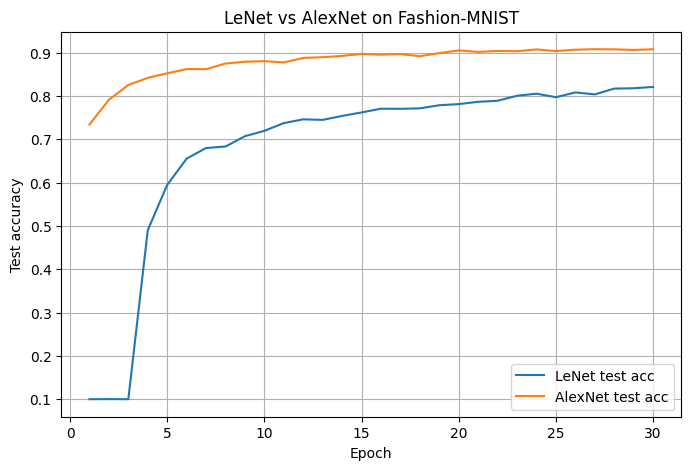

In [9]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, hist_lenet["test_acc"], label="LeNet test acc")
plt.plot(epochs, hist_alexnet["test_acc"], label="AlexNet test acc")
plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("LeNet vs AlexNet on Fashion-MNIST")
plt.legend()
plt.grid(True)
plt.show()

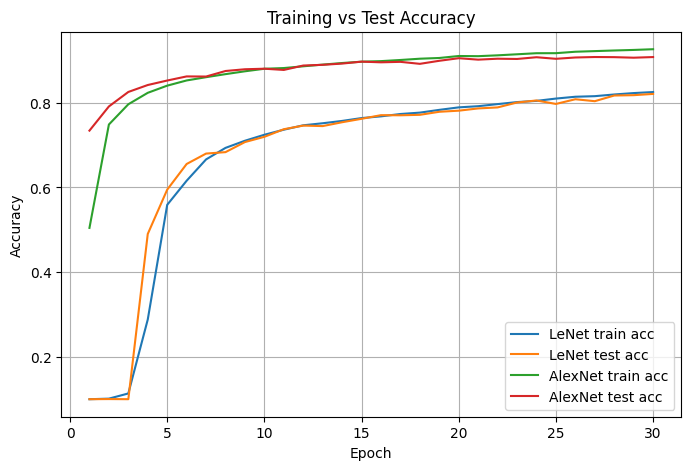

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, hist_lenet["train_acc"], label="LeNet train acc")
plt.plot(epochs, hist_lenet["test_acc"], label="LeNet test acc")
plt.plot(epochs, hist_alexnet["train_acc"], label="AlexNet train acc")
plt.plot(epochs, hist_alexnet["test_acc"], label="AlexNet test acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
print("Average LeNet epoch time:", sum(hist_lenet["epoch_time"]) / len(hist_lenet["epoch_time"]))
print("Average AlexNet epoch time:", sum(hist_alexnet["epoch_time"]) / len(hist_alexnet["epoch_time"]))

print("Peak LeNet GPU memory:", max(hist_lenet["gpu_memory_mb"]), "MB")
print("Peak AlexNet GPU memory:", max(hist_alexnet["gpu_memory_mb"]), "MB")

Average LeNet epoch time: 3.7098275899887083
Average AlexNet epoch time: 28.13786051273346
Peak LeNet GPU memory: 28.62109375 MB
Peak AlexNet GPU memory: 909.41015625 MB


LeNet trains much faster. AlexNet is much slower because it upsamples images to 224×224, has many more channels, and has huge FC layers.

### Exercise 5

In [12]:
class MiniAlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            # Input: 1 x 28 x 28
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 32 x 14 x 14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 64 x 7 x 7

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            # 128 x 7 x 7

            nn.Flatten(),

            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [13]:
batch_size = 128
num_epochs = 30

transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)

test_data = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(
    train_data, batch_size=batch_size, shuffle=True,
    num_workers=2, pin_memory=True
)

test_loader = DataLoader(
    test_data, batch_size=batch_size, shuffle=False,
    num_workers=2, pin_memory=True
)

In [14]:
mini_alexnet = MiniAlexNet()

hist_mini_alexnet = train_model(
    model=mini_alexnet,
    train_loader=train_loader,
    test_loader=test_loader,
    lr=0.01,
    num_epochs=num_epochs,
    model_name="MiniAlexNet"
)

MiniAlexNet | Epoch 01/30 | train acc 0.5054 | test acc 0.7039 | train loss 1.3764 | test loss 0.7758 | time 3.5s | GPU mem 432 MB
MiniAlexNet | Epoch 02/30 | train acc 0.7184 | test acc 0.7559 | train loss 0.7535 | test loss 0.6502 | time 3.6s | GPU mem 432 MB
MiniAlexNet | Epoch 03/30 | train acc 0.7652 | test acc 0.7916 | train loss 0.6357 | test loss 0.5702 | time 3.8s | GPU mem 432 MB
MiniAlexNet | Epoch 04/30 | train acc 0.7868 | test acc 0.8000 | train loss 0.5753 | test loss 0.5411 | time 3.8s | GPU mem 432 MB
MiniAlexNet | Epoch 05/30 | train acc 0.8054 | test acc 0.8139 | train loss 0.5322 | test loss 0.4964 | time 3.7s | GPU mem 432 MB
MiniAlexNet | Epoch 06/30 | train acc 0.8147 | test acc 0.8191 | train loss 0.5045 | test loss 0.4953 | time 3.5s | GPU mem 432 MB
MiniAlexNet | Epoch 07/30 | train acc 0.8235 | test acc 0.8371 | train loss 0.4852 | test loss 0.4482 | time 3.9s | GPU mem 432 MB
MiniAlexNet | Epoch 08/30 | train acc 0.8305 | test acc 0.8418 | train loss 0.4643 

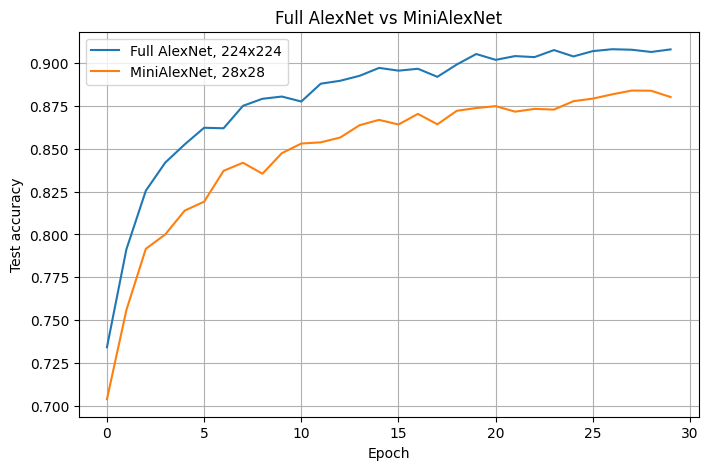

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(hist_alexnet["test_acc"], label="Full AlexNet, 224x224")
plt.plot(hist_mini_alexnet["test_acc"], label="MiniAlexNet, 28x28")
plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("Full AlexNet vs MiniAlexNet")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
print("Full AlexNet avg epoch time:",
      sum(hist_alexnet["epoch_time"]) / len(hist_alexnet["epoch_time"]))

print("MiniAlexNet avg epoch time:",
      sum(hist_mini_alexnet["epoch_time"]) / len(hist_mini_alexnet["epoch_time"]))

print("Full AlexNet peak GPU memory:",
      max(hist_alexnet["gpu_memory_mb"]), "MB")

print("MiniAlexNet peak GPU memory:",
      max(hist_mini_alexnet["gpu_memory_mb"]), "MB")

Full AlexNet avg epoch time: 28.13786051273346
MiniAlexNet avg epoch time: 3.6706104278564453
Full AlexNet peak GPU memory: 909.41015625 MB
MiniAlexNet peak GPU memory: 431.99951171875 MB


The architecture still follows the AlexNet philosophy: Conv → ReLU → MaxPool → Conv → ReLU → MaxPool → FC → Dropout, but with a scale that fits Fashion-MNIST. LeNet is also designed directly for 28×28 images, using two conv blocks and small fully connected layers, so this MiniAlexNet is conceptually between LeNet and full AlexNet.

### Exercise 6

In [18]:
batch_sizes = [32, 64, 128, 256, 512]
num_epochs = 10
lr = 0.01

results = []

for bs in batch_sizes:
    print(f"\n===== Batch size: {bs} =====")

    train_loader = DataLoader(
        train_data,
        batch_size=bs,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_data,
        batch_size=bs,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    model = MiniAlexNet()

    hist = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        lr=lr,
        num_epochs=num_epochs,
        model_name=f"MiniAlexNet-bs{bs}"
    )

    total_train_images = len(train_data) * num_epochs
    total_train_time = sum(hist["epoch_time"])
    throughput = total_train_images / total_train_time

    results.append({
        "batch_size": bs,
        "final_train_acc": hist["train_acc"][-1],
        "final_test_acc": hist["test_acc"][-1],
        "avg_epoch_time": total_train_time / num_epochs,
        "throughput_images_per_sec": throughput,
        "peak_gpu_memory_mb": max(hist["gpu_memory_mb"])
    })


===== Batch size: 32 =====
MiniAlexNet-bs32 | Epoch 01/10 | train acc 0.6767 | test acc 0.7851 | train loss 0.8784 | test loss 0.5683 | time 6.0s | GPU mem 429 MB
MiniAlexNet-bs32 | Epoch 02/10 | train acc 0.8004 | test acc 0.8071 | train loss 0.5447 | test loss 0.4979 | time 5.7s | GPU mem 429 MB
MiniAlexNet-bs32 | Epoch 03/10 | train acc 0.8258 | test acc 0.8443 | train loss 0.4747 | test loss 0.4292 | time 6.0s | GPU mem 429 MB
MiniAlexNet-bs32 | Epoch 04/10 | train acc 0.8453 | test acc 0.8561 | train loss 0.4305 | test loss 0.3978 | time 5.9s | GPU mem 429 MB
MiniAlexNet-bs32 | Epoch 05/10 | train acc 0.8534 | test acc 0.8598 | train loss 0.4027 | test loss 0.3852 | time 5.9s | GPU mem 429 MB
MiniAlexNet-bs32 | Epoch 06/10 | train acc 0.8623 | test acc 0.8679 | train loss 0.3805 | test loss 0.3669 | time 5.8s | GPU mem 429 MB
MiniAlexNet-bs32 | Epoch 07/10 | train acc 0.8689 | test acc 0.8728 | train loss 0.3625 | test loss 0.3501 | time 5.7s | GPU mem 429 MB
MiniAlexNet-bs32 | E

In [19]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df

,batch_size,final_train_acc,final_test_acc,avg_epoch_time,throughput_images_per_sec,peak_gpu_memory_mb
0,32,0.882733,0.8788,5.830937,10289.940587,429.429199
1,64,0.863600,0.8691,4.243605,14138.921045,439.580566
2,128,0.840567,0.8513,3.689996,16260.180630,461.009277
3,256,0.811783,0.8252,3.402310,17635.078015,503.991699
4,512,0.777233,0.7834,3.442941,17426.962643,587.050293


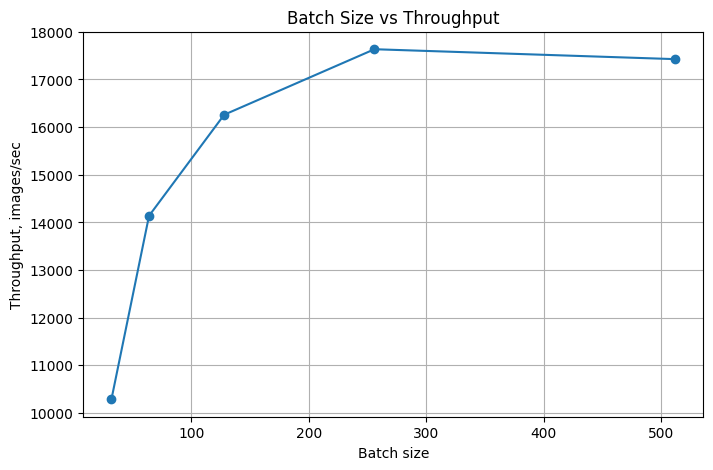

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["batch_size"], results_df["throughput_images_per_sec"], marker="o")
plt.xlabel("Batch size")
plt.ylabel("Throughput, images/sec")
plt.title("Batch Size vs Throughput")
plt.grid(True)
plt.show()

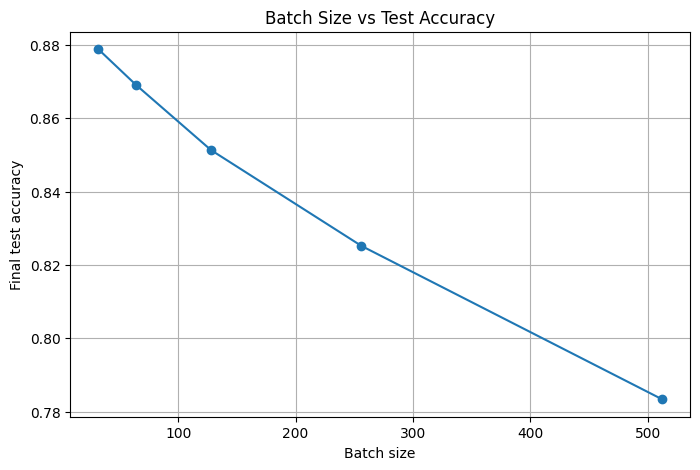

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["batch_size"], results_df["final_test_acc"], marker="o")
plt.xlabel("Batch size")
plt.ylabel("Final test accuracy")
plt.title("Batch Size vs Test Accuracy")
plt.grid(True)
plt.show()

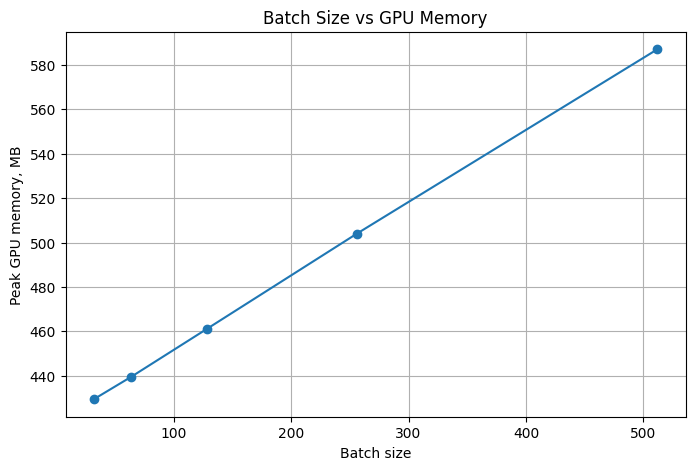

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["batch_size"], results_df["peak_gpu_memory_mb"], marker="o")
plt.xlabel("Batch size")
plt.ylabel("Peak GPU memory, MB")
plt.title("Batch Size vs GPU Memory")
plt.grid(True)
plt.show()

Main intuition:

* Larger batch size improves GPU utilization, so images/sec usually increases.
* GPU memory rises because activations for more images must be stored.
* Accuracy may not monotonically improve. Very large batches can generalize slightly worse or need learning-rate tuning.
* After some point, throughput plateaus because the GPU is already saturated or memory bandwidth becomes the bottleneck.

### Exercise 8

In [27]:
class AlexNetNoDropout(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Flatten(),

            nn.Linear(256 * 5 * 5, 4096),
            nn.ReLU(),

            nn.Linear(4096, 4096),
            nn.ReLU(),

            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [28]:
from torch.utils.data import Subset

# To make overfitting more likely, we can train on a smaller subset of the data. Here we take the first 1000 samples from the training set.
small_train_data = Subset(train_alexnet, range(200))

small_train_loader = DataLoader(
    small_train_data,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [29]:
def train_model_adam(model, train_loader, test_loader, lr, num_epochs, model_name):
    model = model.to(device)
    model.apply(init_weights)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "epoch_time": [],
        "gpu_memory_mb": []
    }

    for epoch in range(num_epochs):
        model.train()
        start = time.time()

        if device.type == "cuda":
            torch.cuda.reset_peak_memory_stats()

        total_loss = 0.0
        correct = 0
        total = 0

        for X, y in train_loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X.shape[0]
            correct += (logits.argmax(dim=1) == y).sum().item()
            total += y.numel()

        train_loss = total_loss / total
        train_acc = correct / total
        test_loss, test_acc = evaluate(model, test_loader)

        epoch_time = time.time() - start
        gpu_memory_mb = torch.cuda.max_memory_allocated() / 1024**2 if device.type == "cuda" else 0

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["epoch_time"].append(epoch_time)
        history["gpu_memory_mb"].append(gpu_memory_mb)

        print(
            f"{model_name} | Epoch {epoch+1:03d}/{num_epochs} | "
            f"train acc {train_acc:.4f} | test acc {test_acc:.4f} | "
            f"train loss {train_loss:.4f} | test loss {test_loss:.4f}"
        )

    return history

In [30]:
alexnet_no_dropout = AlexNetNoDropout()

hist_no_dropout = train_model_adam(
    model=alexnet_no_dropout,
    train_loader=small_train_loader,
    test_loader=test_loader_alexnet,
    lr=1e-4,
    num_epochs=100,
    model_name="AlexNetNoDropout"
)

AlexNetNoDropout | Epoch 001/100 | train acc 0.1100 | test acc 0.2247 | train loss 2.2885 | test loss 2.1980
AlexNetNoDropout | Epoch 002/100 | train acc 0.2800 | test acc 0.3685 | train loss 2.1112 | test loss 1.8012
AlexNetNoDropout | Epoch 003/100 | train acc 0.4500 | test acc 0.3791 | train loss 1.6134 | test loss 1.3325
AlexNetNoDropout | Epoch 004/100 | train acc 0.4800 | test acc 0.5130 | train loss 1.3879 | test loss 1.3971
AlexNetNoDropout | Epoch 005/100 | train acc 0.4550 | test acc 0.5217 | train loss 1.3760 | test loss 1.2908
AlexNetNoDropout | Epoch 006/100 | train acc 0.6000 | test acc 0.4741 | train loss 1.1376 | test loss 1.2275
AlexNetNoDropout | Epoch 007/100 | train acc 0.5700 | test acc 0.6198 | train loss 1.0311 | test loss 0.9873
AlexNetNoDropout | Epoch 008/100 | train acc 0.6800 | test acc 0.6594 | train loss 0.8575 | test loss 0.9443
AlexNetNoDropout | Epoch 009/100 | train acc 0.6750 | test acc 0.5769 | train loss 0.7825 | test loss 1.1629
AlexNetNoDropout | 

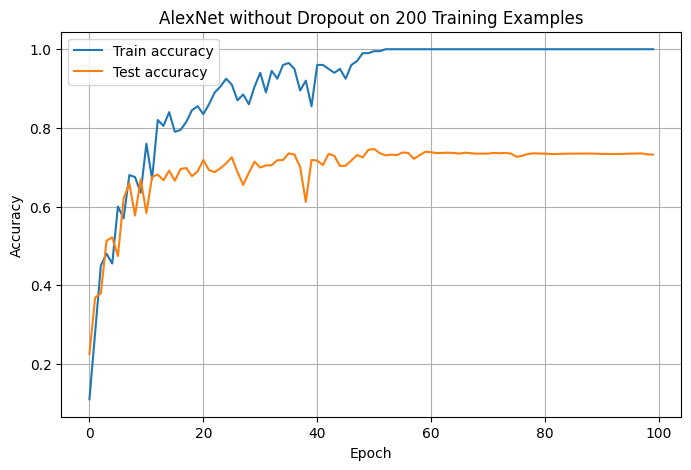

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(hist_no_dropout["train_acc"], label="Train accuracy")
plt.plot(hist_no_dropout["test_acc"], label="Test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("AlexNet without Dropout on 200 Training Examples")
plt.legend()
plt.grid(True)
plt.show()

Remove dropout. Dropout is the key feature preventing the huge fully connected layers from memorizing too aggressively.